<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports
This section imports the libraries used throughout the notebook.

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# Globals

In this section we define the main paths and global variables used by the notebook.

Keeping these variables in one place makes the notebook easier to modify and reduces the risk of inconsistent paths across different experiments.

In [2]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 20
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Repository setup

The project code is stored in a GitHub repository and imported inside Colab.  
If the repository already exists in the working directory, we update it with `git pull`; otherwise, we clone it from GitHub.


In [3]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
Cloning into '/content/REPO'...
remote: Enumerating objects: 282, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 282 (delta 39), reused 21 (delta 9), pack-reused 205 (from 1)
Receiving objects: 100% (282/282), 26.82 MiB | 17.31 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/REPO


# Install dependencies

The required Python packages are installed from `requirements.txt`.

In [4]:
!pip install -q -r requirements.txt

# Utils

This section defines helper functions used to inspect the dataset, verify paths, load evaluation metrics, and visualize saved results.

In [5]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


In [6]:
def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')

In [7]:
def show_evaluation_outputs(output_dir):
    """
    Show evaluation metrics and confusion matrices saved by evaluate_RGB.py.
    """

    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics.json"

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    # Load metrics saved by evaluate_RGB.py.
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    # Convert metrics dictionary into a readable table.
    rows = []

    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            for sub_metric_name, sub_value in value.items():
                rows.append({
                    "Metric": metric_name,
                    "Group": sub_metric_name,
                    "Value": sub_value,
                })
        else:
            rows.append({
                "Metric": metric_name,
                "Group": "-",
                "Value": value,
            })

    metrics_df = pd.DataFrame(rows)

    # Format numeric values to 4 decimals.
    if not metrics_df.empty:
        metrics_df["Value"] = metrics_df["Value"].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
        )

    print("Evaluation metrics")
    display(metrics_df)

    # Show saved confusion matrices as images.
    fake_cm_path = output_dir / "confusion_fake.png"
    transform_cm_path = output_dir / "confusion_transform.png"

    if fake_cm_path.exists():
        print("\nReal/Fake confusion matrix")
        display(Image(filename=str(fake_cm_path)))

    if transform_cm_path.exists():
        print("\nTransformation confusion matrix")
        display(Image(filename=str(transform_cm_path)))

    if not fake_cm_path.exists() and not transform_cm_path.exists():
        print("\nNo confusion matrix images found in this folder.")

# Data preparation and inspection

Before training any model, we inspect the dataset splits and verify that the image paths are correctly resolved.

The project uses a balanced subset of RRDataset, containing both real and AI-generated images across three transformation categories:

- original images;
- internet-transmitted images;
- re-digitized images.



In [8]:
train_df = show_csv_summary(TRAIN_CSV)

File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [9]:
val_df = show_csv_summary(VAL_CSV)

File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [10]:
test_df = show_csv_summary(TEST_CSV)

File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


The dataset is downloaded only if the zip file is not already available and extracted only if the target image folder does not already exist.

In [11]:
# Download the dataset only if the zip file is not already available.
if not Path(DATASET_ZIP_PATH).exists():
    print("Dataset zip not found. Downloading it with gdown...")
    os.system(f'gdown --id "{DATASET_FILE_ID}" -O "{DATASET_ZIP_PATH}"')
else:
    print(f"Dataset zip already exists: {DATASET_ZIP_PATH}")

Dataset zip not found. Downloading it with gdown...


In [12]:
# Extract the dataset only if the extracted folder is not already available.
IMAGE_ROOT = Path(IMAGE_ROOT)
if not IMAGE_ROOT.exists():
    print("Extracted dataset folder not found. Extracting...")
    os.system(f'mkdir -p "{IMAGE_ROOT.parent}"')
    os.system(f'unzip -q "{DATASET_ZIP_PATH}" -d "{IMAGE_ROOT.parent}"')
else:
    print(f"Dataset already extracted: {IMAGE_ROOT}")

Extracted dataset folder not found. Extracting...


We verify that the image paths listed in the CSV files actually exist inside the dataset folder: if paths are wrong, training would fail later during data loading.

In [13]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)

Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# RGB baselines

The first group of experiments uses only the RGB image as input.

We train and evaluate:

1. a **single-task real/fake baseline**;
2. a **single-task transformation baseline**;
3. several **RGB multi-task baselines** with different loss weightings.

This allows us to understand whether joint learning improves, hurts, or leaves unchanged the performance of the two tasks.

## Single-task Real/Fake baseline

This baseline trains the RGB model only on the binary real/fake task.

Its purpose is to measure how well a standard RGB model can distinguish real images from AI-generated images without receiving any supervision about post-processing transformations.

In [14]:
# Train the real/fake single-task baseline.
!python src/train_RGB.py \
  --task fake \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_fake.pt

Selected task: fake
Using device: cuda
Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 682, in <module>
    main()
  File "/content/REPO/src/train_RGB.py", line 543, in main
    model = RGBMultiTaskModel(
            ^^^^^^^^^^^^^^^^^^
  File "/content/REPO/src/model_RGB.py", line 48, in __init__
    backbone = models.resnet18(weights=weights)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py", line 142, in wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py", line 228, in inner_wrapper
    return builder(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/resnet.py", line 705, in resnet18
    return _resnet(BasicBlock, [2, 2, 2, 2], weights, progress, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

We evaluate the fake-only model on the test split and report global real/fake metrics.

In [15]:
# Evaluate the real/fake single-task baseline.
!python src/evaluate_RGB.py \
  --task fake \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_fake.pt \
  --output_dir results/rgb_fake \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 442, in <module>
    from torch._C import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 463, in _lock_unlock_module
KeyboardInterrupt
^C


The following outputs summarize the fake-only baseline:

- global real/fake accuracy;
- macro F1-score;
- real/fake accuracy by transformation type;
- real/fake confusion matrix.

In [16]:
show_evaluation_outputs("results/rgb_fake")

Metrics file not found: results/rgb_fake/metrics.json


## Single-task Transformation baseline

This baseline trains the RGB model only on the transformation classification task.

The model predicts whether an image is original, internet-transmitted, or re-digitized.  
This experiment helps us measure how recognizable post-processing traces are when the model is not simultaneously optimized for real/fake detection.

In [17]:
# Train the transformation single-task baseline.
!python src/train_RGB.py \
  --task transform \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_transform.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 9, in <module>
    from dataset import RRDatasetFromCSV, build_train_transform, build_eval_transform
  File "/content/REPO/src/dataset.py", line 3, in <module>
    import pandas as pd
  File "/usr/local/lib/python3.12/dist-packages/pandas/__init__.py", line 26, in <module>
    from pandas.compat import (
  File "/usr/local/lib/python3.12/dist-packages/pandas/compat/__init__.py", line 27, in <module>
    from pandas.compat.pyarrow import (
  File "/usr/local/lib/python3.12/dist-packages/pandas/compat/pyarrow.py", line 8, in <module>
    import pyarrow as pa
  File "/usr/local/lib/python3.12/dist-packages/pyarrow/__init__.py", line 65, in <module>
    import pyarrow.lib as _lib
  File "<frozen importlib._bootstrap>", line 645, in parent
KeyboardInterrupt
^C


We evaluate the transformation-only model on the test split and report transformation accuracy, macro F1-score, and the transformation confusion matrix.

In [18]:
# Evaluate the transformation single-task baseline.
!python src/evaluate_RGB.py \
  --task transform \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_transform.pt \
  --output_dir results/rgb_transform \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2273, in <module>
    from torch import (
  File "/usr/local/lib/python3.12/dist-packages/torch/distributions/__init__.py", line 96, in <module>
    from .kl import _add_kl_info, kl_divergence, register_kl
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1128, in get_code
  File "<frozen importlib._bootstrap_external>", line 757, in _compile_bytecode
KeyboardInterrupt
^C


In [19]:
show_evaluation_outputs("results/rgb_transform")

Metrics file not found: results/rgb_transform/metrics.json


## RGB Multi-task baseline - manual weights 1.0 / 1.0

This is the standard multi-task baseline.

The model uses a shared RGB backbone and two independent classification heads:

- one head predicts the real/fake label;
- one head predicts the transformation label.

The total loss is computed as:

**L = 1.0 × L_fake + 1.0 × L_transform**

This setting gives equal importance to both tasks.

In [20]:
# Train the joint RGB multi-task baseline with weights 1 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_1_1.pt

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 2394, in <module>
    prod = _make_reduction_prim(
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 2333, in _make_reduction_prim
    return _make_prim(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 334, in _make_prim
    prim_def = torch.library.custom_op(
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py", line 176, in custom_op
    return inner(fn)
           ^^^^^^^^^
  File "/usr/local/lib/

In [21]:
# Evaluate the joint RGB multi-task baseline with weights 1 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_1.pt \
  --output_dir results/rgb_multitask_1_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 442, in <module>
    from torch._C import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 463, in _lock_unlock_module
KeyboardInterrupt
^C


In [22]:
show_evaluation_outputs("results/rgb_multitask_1_1")

Metrics file not found: results/rgb_multitask_1_1/metrics.json


## RGB Multi-task baseline - manual weights 1.0 / 2.0

In this experiment, the transformation loss receives a higher weight than the real/fake loss:

**L = 1.0 × L_fake + 2.0 × L_transform**

The goal is to test whether forcing the model to focus more on transformation recognition also improves real/fake detection.

In [23]:
# Train the joint RGB multi-task baseline with weights 1 2.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name best_rgb_multitask_1_2.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 4, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2273, in <module>
    from torch import (
  File "/usr/local/lib/python3.12/dist-packages/torch/distributions/__init__.py", line 117, in <module>
    from .von_mises import VonMises
  File "/usr/local/lib/python3.12/dist-packages/torch/distributions/von_mises.py", line 5, in <module>
    import torch.jit
  File "/usr/local/lib/python3.12/dist-packages/torch/jit/__init__.py", line 24, in <module>
    from torch.jit._async import fork, wait
  File "/usr/local/lib/python3.12/dist-packages/torch/jit/_async.py", line 131, in <module>
    _register_builtin(wait, "aten::wait")
  File "/usr/local/lib/python3.12/dist-packages/torch/jit/_builtins.py", line 200, in _register_builtin
    _get_builtin_table()[id(fn)] = op
    ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/jit/_builtins.py

In [24]:
# Evaluate the joint RGB multi-task baseline with weights 1 2.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_2.pt \
  --output_dir results/rgb_multitask_1_2 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 442, in <module>
    from torch._C import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 463, in _lock_unlock_module
KeyboardInterrupt
^C


In [25]:
show_evaluation_outputs("results/rgb_multitask_1_2")

Metrics file not found: results/rgb_multitask_1_2/metrics.json


## RGB Multi-task baseline - manual weights 1.0 / 2.0

In this experiment, the real/fake loss receives a higher weight than the transformation loss:

**L = 2.0 × L_fake + 1.0 × L_transform**

This setting prioritizes the main forensic task while still keeping transformation classification as an auxiliary task.

In [26]:
# Train the joint RGB multi-task baseline with weights 2 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 2.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_2_1.pt

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torchvision/ops/__init__.py", line 23, in <module>
    from .poolers import MultiScaleRoIAlign
  File "/usr/local/lib/python3.12/dist-packages/torchvision/ops/poolers.py", line 10, in <module>
    from .roi_align import roi_align
  File "/usr/local/lib/python3.12/dist-packages/torchvision/ops/roi_align.py", line 7, in <module>
    from torch._dynamo.utils import is_compile_supported
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/__init__.py", line 13, in <module>
    from . import (
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/aot_compile.py", line 15, in <module>
    from torch.

In [27]:
# Evaluate the joint RGB multi-task baseline with weights 2 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_2_1.pt \
  --output_dir results/rgb_multitask_2_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2229, in <module>
    from torch import _VF as _VF, functional as functional  # usort: skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/functional.py", line 8, in <module>
    import torch.nn.functional as F
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/__init__.py", line 8, in <module>
    from torch.nn.modules import *  # usort: skip # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/__init__.py", line 53, in <module>
    from .conv import (
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py", line 10, in <module>
    from torch.nn.common_types import _size_1_t, _size_2_t, _size_3_t
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/common_types.py

In [28]:
show_evaluation_outputs("results/rgb_multitask_2_1")

Metrics file not found: results/rgb_multitask_2_1/metrics.json


## RGB Multi-task baseline - Learned Uncertainty Weighting

This experiment replaces manually selected loss weights with learned uncertainty-based weights.

Instead of fixing the relative importance of the two tasks before training, the model learns how much each task should contribute to the total loss.

This is useful because the two tasks may have different difficulty levels. If one task is noisier or harder, the learned weighting mechanism can reduce its dominance and make the multi-task optimization more balanced.

In [29]:
# Train the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/train_RGB.py \
  --task multitask \
  --loss_weighting learned \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_multitask_learned_weights.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 9, in <module>
    from dataset import RRDatasetFromCSV, build_train_transform, build_eval_transform
  File "/content/REPO/src/dataset.py", line 8, in <module>
    from torchvision import transforms
  File "/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py", line 8, in <module>
    from torchvision import _meta_registrations, datasets, io, models, ops, transforms, utils  # usort:skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/__init__.py", line 2, in <module>
    from .convnext import *
  File "/usr/local/lib/python3.12/dist-packages/torchvision/models/convnext.py", line 9, in <module>
    from ..ops.misc import Conv2dNormActivation, Permute
  File "/usr/local/lib/python3.12/dist-packages/torchvision/ops/__init__.py", line 23, in <module>
    from .poolers import MultiScaleRoI

In [30]:
# Evaluate the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_learned_weights.pt \
  --output_dir results/rgb_multitask_learned_weights \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2804, in <module>
    from torch import _meta_registrations
  File "/usr/local/lib/python3.12/dist-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/__init__.py", line 287, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 1953, in <module>
    rev = _make_prim(
          ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 334, in _make_prim
    prim_def = torch.library.custom_op(
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/p

In [31]:
show_evaluation_outputs("results/rgb_multitask_learned_weights")

Metrics file not found: results/rgb_multitask_learned_weights/metrics.json


## Results Comparison and Ablation Study

This section compares the RGB baselines and the RGB multi-task models.

The objective is to understand whether the transformation task helps the real/fake detector learn more robust features, or whether the two objectives interfere with each other during training.

We also compare different loss-weighting strategies, since changing the relative importance of the two losses can affect the balance between real/fake accuracy and transformation accuracy.

Finally, we report real/fake accuracy by transformation type to check whether the model remains reliable on original, transmitted, and re-digitized images.

In [32]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}

rows = []

for model_name, metrics_path in results.items():
    metrics_path = Path(metrics_path)

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    rows.append({
        "model": model_name,
        "fake_accuracy": metrics.get("fake_accuracy"),
        "fake_f1_macro": metrics.get("fake_f1_macro"),
        "transform_accuracy": metrics.get("transform_accuracy"),
        "transform_f1_macro": metrics.get("transform_f1_macro"),
        "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
        "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
        "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(
    by=["fake_accuracy", "transform_accuracy"],
    ascending=False
)

Missing file: results/rgb_fake/metrics.json
Missing file: results/rgb_transform/metrics.json
Missing file: results/rgb_multitask_1_1/metrics.json
Missing file: results/rgb_multitask_1_2/metrics.json
Missing file: results/rgb_multitask_2_1/metrics.json
Missing file: results/rgb_multitask_learned_weights/metrics.json


KeyError: 'fake_accuracy'

### Global accuracy comparison

The following plot compares the main accuracy scores across RGB experiments.

In [ ]:
# Global Accuracy Comparison

plot_df = comparison_df.set_index("model")

plot_df[["fake_accuracy", "transform_accuracy"]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Global Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Real/Fake accuracy by transformation type

This analysis breaks down real/fake detection accuracy across transformation categories.

This is important because the main challenge of the project is not only detecting AI-generated images in clean conditions, but also maintaining robustness after real-world post-processing.

In [ ]:
# Real/Fake Accuracy by Transformation Type
plot_df[[
    "fake_acc_original",
    "fake_acc_transfer",
    "fake_acc_redigital",
]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Real/Fake Accuracy by Transformation Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

##ViT


#Frequency

GANs genereate periodic artifacts, invisibles in RGB, but that can be detect in frequency domain.
Is used FFT on the amplitude log-spectrum.



##Standard Applycation
lambda_fake=1.0 and lambda_transform=2.0 in order to improve trasformation evaluetion, that is the critical aspect in RGB.


**TRAIN**

In [ ]:
# Frequency multi-task using weights 1.0 / 1.0
!python src/train_freq.py \
  --train_csv        {TRAIN_CSV} \
  --val_csv          {VAL_CSV} \
  --image_root       {IMAGE_ROOT} \
  --epochs           {EPOCHS} \
  --batch_size       {BATCH_SIZE} \
  --image_size       {IMAGE_SIZE} \
  --num_workers      {NUM_WORKERS} \
  --lambda_fake      1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name  best_freq_multitask_1_1.pt

**EVALUATE**

In [ ]:
!python src/evaluate_freq.py \
  --csv_path    {TEST_CSV} \
  --image_root  {IMAGE_ROOT} \
  --checkpoint  checkpoints/best_freq_multitask_1_1.pt \
  --output_dir  results/freq_multitask_1_1 \
  --batch_size  {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

**RESULTS**

In [ ]:
show_evaluation_outputs("results/freq_multitask_1_1")

**COMPARISON**

In [ ]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}
results["Freq multitask 1-1"] = "results/freq_multitask_1_1/metrics.json"

##Improvement
**Different training Cosine scheduler with warm-up and Learned uncertainty weighting**

In [ ]:
!python src/FrequencyAugumented.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs 20 \
  --batch_size {BATCH_SIZE} \
  --num_workers {NUM_WORKERS} \
  --scheduler cosine \
  --warmup_epochs 2 \
  --loss_weighting learned \
  --checkpoint_name best_freq_learned_cosine.pt

**Evaluation**

In [ ]:
!python src/evaluate_freq.py \
  --csv_path    {TEST_CSV} \
  --image_root  {IMAGE_ROOT} \
  --checkpoint  checkpoints/best_freq_multitask_1_1.pt \
  --output_dir  results/freq_multitask_1_1 \
  --batch_size  {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

**Results**

**Comparison**

##Ablation Study

##ViT

**TRAIN**

In [ ]:
!python src/train_vit.py \
  --train_csv  {TRAIN_CSV} \
  --val_csv    {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs     {EPOCHS} \
  --batch_size 16 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_vit_multitask_1_1.pt

**Evalutation**

In [ ]:
!python src/evaluate_vit.py \
  --csv_path   {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_vit_multitask_1_1.pt \
  --output_dir results/vit_multitask_1_1 \
  --batch_size 16 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

**Comparison**

In [ ]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}
results["ViT multitask 1-1"] = "results/vit_multitask_1_1/metrics.json"

#DEPTH

In [ ]:
!find /content -name "real_006970.jpg"

##Depth map generation

###first small debug

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV}\
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small \
  --max_images 5

###full depth map generation

In [33]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small

Using device: cuda
Number of images to process: 3000
Loading pretrained MiDaS model: MiDaS_small
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt
100% 81.8M/81.8M [00:00

In [34]:
from pathlib import Path

DRIVE_DEPTH_ROOT = Path("/content/drive/MyDrive/CV_Project/depth_maps")
LOCAL_DEPTH_ROOT = Path("/content/depth_maps")
DEPTH_ROOT = str(LOCAL_DEPTH_ROOT)

DRIVE_DEPTH_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_DEPTH_ROOT.mkdir(parents=True, exist_ok=True)

# Count existing depth maps on Drive
drive_depth_files = list(DRIVE_DEPTH_ROOT.rglob("*.npy"))

print(f"Depth maps found on Drive: {len(drive_depth_files)}")

if len(drive_depth_files) == 0:
    print("No depth maps found on Drive. Generating them once and saving directly to Drive...")

    !python src/generate_depth_map.py \
      --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
      --image_root {IMAGE_ROOT} \
      --depth_root "{DRIVE_DEPTH_ROOT}" \
      --model_type MiDaS_small

else:
    print("Depth maps already exist on Drive. No need to regenerate them.")

# Copy depth maps from Drive to local /content for faster training/evaluation
print("Copying depth maps from Drive to local /content...")
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = str(LOCAL_DEPTH_ROOT)

print("Local DEPTH_ROOT:", DEPTH_ROOT)
print("Some local depth maps:")
!find "{DEPTH_ROOT}" -type f -name "*.npy" | head

Depth maps found on Drive: 3000
Depth maps already exist on Drive. No need to regenerate them.
Copying depth maps from Drive to local /content...
 15,795,119,360 100%  101.28MB/s    0:02:28 (xfr#3000, to-chk=0/3010)
Local DEPTH_ROOT: /content/depth_maps
Some local depth maps:
/content/depth_maps/redigital/ai/redigital_production_000137.npy
/content/depth_maps/redigital/ai/redigital_normal_009846.npy
/content/depth_maps/redigital/ai/redigital_Medical_&_Public_Health_000984.npy
/content/depth_maps/redigital/ai/redigital_normal_007701.npy
/content/depth_maps/redigital/ai/redigital_War_&_Conflict_Scenes_000698.npy
/content/depth_maps/redigital/ai/redigital_Natural_Disasters_&_Accidents_000028.npy
/content/depth_maps/redigital/ai/redigital_Medical_&_Public_Health_000129.npy
/content/depth_maps/redigital/ai/redigital_War_&_Conflict_Scenes_000298.npy
/content/depth_maps/redigital/ai/redigital_War_&_Conflict_Scenes_000318.npy
/content/depth_maps/redigital/ai/redigital_Medical_&_Public_Health_0

##copy of depth maph in local so colab doesn't need to go on drive every time

In [ ]:
DRIVE_DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"
LOCAL_DEPTH_ROOT = "/content/depth_maps"

!mkdir -p "{LOCAL_DEPTH_ROOT}"
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = LOCAL_DEPTH_ROOT

print("Depth maps will be loaded from:", DEPTH_ROOT)

##First try with depth only

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting \
  --no_edge

The edge-consistency branch introduces additional geometric information, but also increases model complexity. This leads to mild overfitting and a small decrease in real/fake validation accuracy, although transformation classification slightly improves.
We should use only depth without edge

##Evaluate RGB+Depth no edge

saves on drive not only local

In [ ]:
DRIVE_CKPT_ROOT = "/content/drive/MyDrive/CV_Project/checkpoints"

!mkdir -p "{DRIVE_CKPT_ROOT}"
!cp /content/REPO/checkpoints/*.pt "{DRIVE_CKPT_ROOT}/"

!ls "{DRIVE_CKPT_ROOT}"

puts again in local

In [ ]:
DRIVE_CKPT_ROOT = "/content/drive/MyDrive/CV_Project/checkpoints"
LOCAL_CKPT_ROOT = "/content/REPO/checkpoints"

!mkdir -p "{LOCAL_CKPT_ROOT}"
!cp "{DRIVE_CKPT_ROOT}"/*.pt "{LOCAL_CKPT_ROOT}/"

!ls "{LOCAL_CKPT_ROOT}"

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/depth_only \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge

In [ ]:
show_evaluation_outputs("results/depth_only")

##Second try with also edge consistency

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_edge_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

#Evaluate RGB+Depth+edge

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/depth_edge \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

In [ ]:
show_evaluation_outputs("results/depth_edge")

##grad-cam

real

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 1 \
  --shuffle

transform

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 1 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 2 \
  --shuffle

In [ ]:
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

#comparison depth with depth+edge

In [49]:


import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def build_comparison_df(results_dict):
    rows = []

    for model_name, metrics_path in results_dict.items():
        metrics_path = Path(metrics_path)

        if not metrics_path.exists():
            print(f"Missing file: {metrics_path}")
            continue

        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        rows.append({
            "model": model_name,
            "fake_accuracy": metrics.get("fake_accuracy"),
            "fake_f1_macro": metrics.get("fake_f1_macro"),
            "transform_accuracy": metrics.get("transform_accuracy"),
            "transform_f1_macro": metrics.get("transform_f1_macro"),
            "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
            "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
            "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
        })

    comparison_df = pd.DataFrame(rows)

    if len(comparison_df) > 0:
        comparison_df = comparison_df.sort_values(
            by=["fake_accuracy", "transform_accuracy"],
            ascending=False,
        )

    return comparison_df


def plot_global_accuracy(comparison_df, title):
    plot_df = comparison_df.set_index("model")

    plot_df[["fake_accuracy", "transform_accuracy"]].plot(
        kind="bar",
        figsize=(12, 5),
    )

    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_fake_accuracy_by_transformation(comparison_df, title):
    plot_df = comparison_df.set_index("model")

    plot_df[[
        "fake_acc_original",
        "fake_acc_transfer",
        "fake_acc_redigital",
    ]].plot(
        kind="bar",
        figsize=(12, 5),
    )

    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

In [ ]:
depth_results = {
    "RGB + Depth": "results/depth_only/metrics.json",
    "RGB + Depth + Edge": "results/depth_edge/metrics.json",
}

depth_comparison_df = build_comparison_df(depth_results)

depth_comparison_df


plot_global_accuracy(
    depth_comparison_df,
    "Depth Ablation: Global Accuracy Comparison"
)



plot_fake_accuracy_by_transformation(
    depth_comparison_df,
    "Depth Ablation: Real/Fake Accuracy by Transformation Type"
)




#DEPTH+FREQUENCY

In [ ]:
print(EPOCHS)
print(type(EPOCHS))

!echo {EPOCHS}

In [35]:
!python src/train_depth_frequency.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_uncertainty.pt \
  --checkpoint_dir checkpoints \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 135MB/s]

Epoch 1/20
Training RGB+Depth+Frequency: 100% 66/66 [01:41<00:00,  1.53s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:27<00:00,  1.83s/it]
Train: {'loss': 1.4370370858056205, 'fake_acc': 0.8371428571428572, 'transform_acc': 0.4119047619047619, 'weight_fake': 1.003549454790173, 'weight_transform': 0.9971480784994183}
Val:   {'loss': 1.148399623102612, 'fake_acc': 0.88, 'transform_acc': 0.5422222222222223, 'weight_fake': 1.0075215101242065, 'weight_transform': 0.9955950975418091}
Val score: 0.7111
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_frequency_uncertainty.pt

Epoch 2/20
Training RGB+Depth+Frequency: 100% 66/66 [01:42<00:00,  1.55s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:27<00:00,  1.84s/it]
Train: {'loss': 0.8514698698407128, 'fake_acc': 0.9604761

In [37]:
from pathlib import Path
import shutil

# Permanent Drive folder
DRIVE_CKPT_ROOT = Path("/content/drive/MyDrive/CV_Project/checkpoints")

# Local temporary Colab folder
LOCAL_CKPT_ROOT = Path("/content/REPO/checkpoints")

# Safety checks
if not Path("/content/drive/MyDrive").exists():
    raise RuntimeError("Drive is not mounted. Run drive.mount('/content/drive') first.")

if not LOCAL_CKPT_ROOT.exists():
    raise RuntimeError(f"Local checkpoint folder not found: {LOCAL_CKPT_ROOT}")

# Create permanent folder on Drive
DRIVE_CKPT_ROOT.mkdir(parents=True, exist_ok=True)

# Copy every .pt checkpoint to Drive
checkpoint_files = list(LOCAL_CKPT_ROOT.glob("*.pt"))

if len(checkpoint_files) == 0:
    print("No .pt checkpoint files found in:", LOCAL_CKPT_ROOT)
else:
    for checkpoint_path in checkpoint_files:
        destination = DRIVE_CKPT_ROOT / checkpoint_path.name
        shutil.copy2("/content/REPO/checkpoints/best_depth_frequency_uncertainty.pt/best_depth_frequency_uncertainty.pt", destination)
        print(f"Saved: {checkpoint_path.name} -> {destination}")

print("\nCheckpoints currently saved on Drive:")
for file in sorted(DRIVE_CKPT_ROOT.glob("*.pt")):
    print(file.name)

NotADirectoryError: [Errno 20] Not a directory: '/content/REPO/checkpoints/best_depth_frequency_uncertainty.pt/best_depth_frequency_uncertainty.pt'

##evaluate

In [38]:
from pathlib import Path
import shutil
import time

LOCAL_CKPT_ROOT = Path("/content/REPO/checkpoints")
DRIVE_CKPT_ROOT = Path("/content/drive/MyDrive/CV_Project/checkpoints")

BAD_PATH = LOCAL_CKPT_ROOT / "best_depth_frequency_uncertainty.pt"
FINAL_FILE = LOCAL_CKPT_ROOT / "best_depth_frequency_uncertainty.pt"
DRIVE_FINAL_FILE = DRIVE_CKPT_ROOT / "best_depth_frequency_uncertainty.pt"

DRIVE_CKPT_ROOT.mkdir(parents=True, exist_ok=True)

if not BAD_PATH.exists():
    raise RuntimeError(f"Path not found: {BAD_PATH}")

if BAD_PATH.is_file():
    print("Good news: this is already a file, not a directory.")
    print(BAD_PATH)

elif BAD_PATH.is_dir():
    print("Found wrong directory:", BAD_PATH)

    # 1. Backup the whole wrong folder to Drive before deleting anything.
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    BACKUP_DIR = DRIVE_CKPT_ROOT / f"backup_wrong_checkpoint_folder_{timestamp}"

    shutil.copytree(BAD_PATH, BACKUP_DIR)
    print("Backup of wrong folder saved to Drive:")
    print(BACKUP_DIR)

    # 2. Search for real .pt checkpoint files inside the wrong folder.
    candidates = sorted(
        BAD_PATH.rglob("*.pt"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    print("\nCandidate checkpoint files found inside wrong folder:")
    for i, candidate in enumerate(candidates):
        size_mb = candidate.stat().st_size / (1024 * 1024)
        print(f"{i}: {candidate} | {size_mb:.2f} MB")

    if len(candidates) == 0:
        raise RuntimeError(
            "No real .pt file found inside the wrong folder. "
            "Nothing was deleted. Check the backup folder on Drive."
        )

    # 3. Choose the newest .pt file as the real checkpoint.
    chosen_checkpoint = candidates[0]
    print("\nChosen checkpoint:")
    print(chosen_checkpoint)

    # 4. Copy chosen checkpoint to a temporary safe location.
    TEMP_SAFE_FILE = Path("/content/best_depth_frequency_uncertainty_SAFE.pt")
    shutil.copy2(chosen_checkpoint, TEMP_SAFE_FILE)
    print("\nTemporary safe copy created:")
    print(TEMP_SAFE_FILE)

    # 5. Save chosen checkpoint permanently to Drive.
    shutil.copy2(chosen_checkpoint, DRIVE_FINAL_FILE)
    print("\nPermanent checkpoint saved to Drive:")
    print(DRIVE_FINAL_FILE)

    # 6. Remove the wrong directory.
    shutil.rmtree(BAD_PATH)
    print("\nRemoved wrong directory:")
    print(BAD_PATH)

    # 7. Put the real checkpoint file back with the correct name.
    shutil.copy2(TEMP_SAFE_FILE, FINAL_FILE)
    print("\nCorrect checkpoint file restored locally:")
    print(FINAL_FILE)

else:
    raise RuntimeError(f"Unexpected path type: {BAD_PATH}")

print("\nFinal check:")
!ls -lh /content/REPO/checkpoints
print("\nDrive check:")
!ls -lh /content/drive/MyDrive/CV_Project/checkpoints

Good news: this is already a file, not a directory.
/content/REPO/checkpoints/best_depth_frequency_uncertainty.pt

Final check:
total 140M
-rw-r--r-- 1 root root 140M Jul  3 20:51 best_depth_frequency_uncertainty.pt

Drive check:
total 0


In [39]:
!python src/evaluation_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/depth_frequency_uncertainty \
  --batch_size {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Using device: cuda
Evaluating RGB+Depth+Frequency: 100% 15/15 [00:22<00:00,  1.48s/it]

Evaluation results
------------------
Fake accuracy:        0.9244
Fake F1 macro:        0.9243
Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9400
  redigital: 0.9000
Transform accuracy:   0.8067
Transform F1 macro:   0.8065

Saved results in: results/depth_frequency_uncertainty


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9244
1,fake_f1_macro,-,0.9243
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9400
4,fake_accuracy_by_transform,redigital,0.9000
5,transform_accuracy,-,0.8067
6,transform_f1_macro,-,0.8065
7,fake_classification_report,real,"{'precision': 0.889795918367347, 'recall': 0.9..."
8,fake_classification_report,fake,"{'precision': 0.9658536585365853, 'recall': 0...."
9,fake_classification_report,accuracy,0.9244



Real/Fake confusion matrix


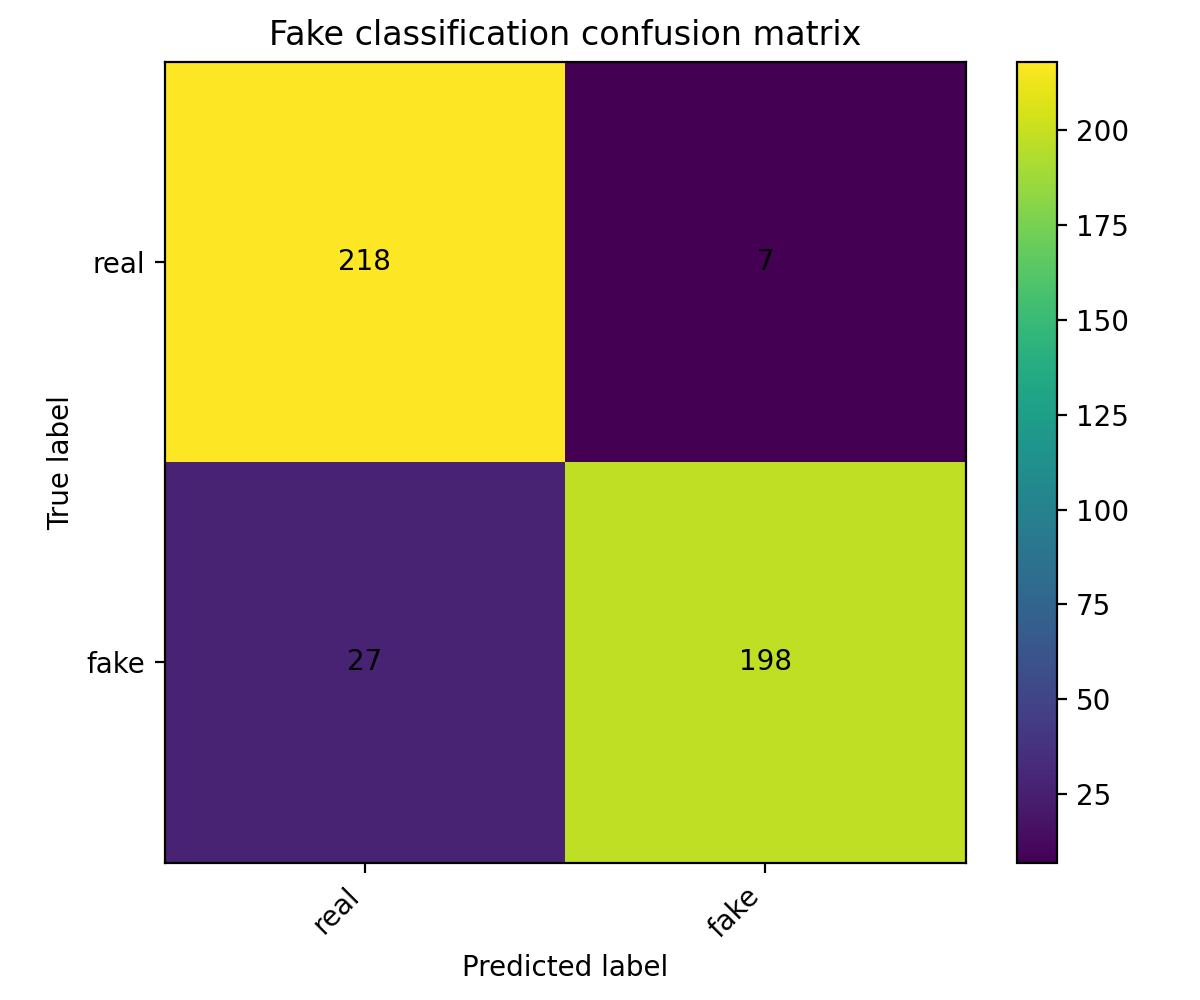


Transformation confusion matrix


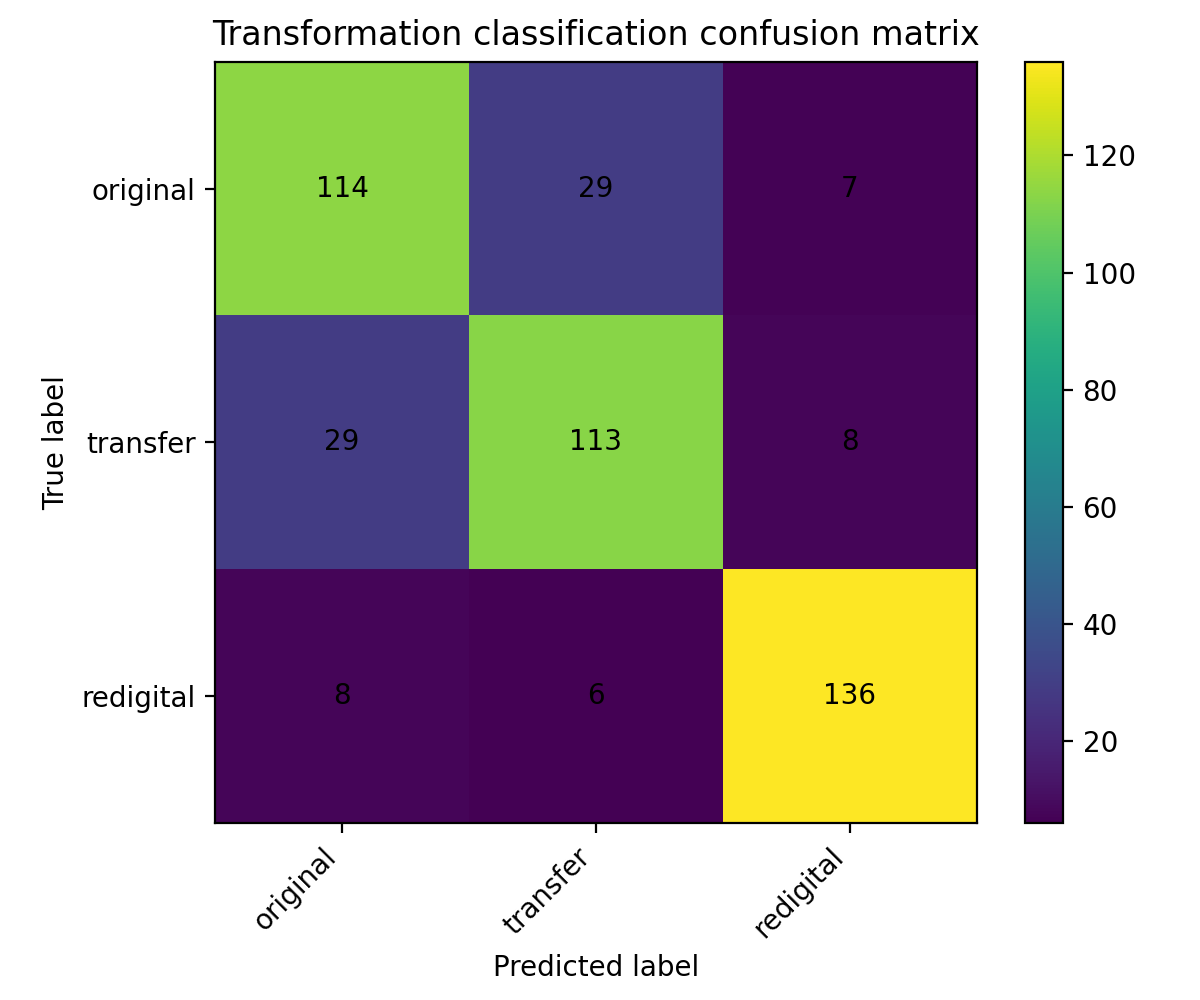

In [40]:
show_evaluation_outputs("results/depth_frequency_uncertainty")

##gradcam

In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 0 \
  --shuffle


In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 1 \
  --shuffle


In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 0 \
  --shuffle



In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 1 \
  --shuffle



In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint /content/drive/MyDrive/CV_Project/checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 2 \
  --shuffle

In [ ]:
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth_frequency")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

maybe this saves checkpoint for real

In [ ]:
from pathlib import Path

DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/CV_Project")
DRIVE_CHECKPOINT_DIR = DRIVE_PROJECT_ROOT / "checkpoints"
LOCAL_CHECKPOINT_DIR = Path("/content/REPO/checkpoints")

DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

!rsync -a --info=progress2 "{LOCAL_CHECKPOINT_DIR}/" "{DRIVE_CHECKPOINT_DIR}/"

print("Saved checkpoints permanently on Drive:")
!find "{DRIVE_CHECKPOINT_DIR}" -type f -name "*.pt" -exec ls -lh {{}} \;

#depth frequency gated

In [ ]:
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/CV_Project/checkpoints"

In [45]:
!python src/train_depth_frequency_gated.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_gated_uncertainty.pt \
  --checkpoint_dir checkpoints \
  --epochs 10 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

Using device: cuda

Epoch 1/10
Training RGB+Depth+Frequency: 100% 66/66 [01:44<00:00,  1.58s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:27<00:00,  1.86s/it]
Train: {'loss': 1.4541880880083358, 'fake_acc': 0.8171428571428572, 'transform_acc': 0.42333333333333334, 'weight_fake': 1.0035340894352307, 'weight_transform': 0.9971109601584348}
Val:   {'loss': 1.1239821704228719, 'fake_acc': 0.9, 'transform_acc': 0.56, 'weight_fake': 1.0075258016586304, 'weight_transform': 0.9953625798225403}
Val score: 0.7300
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_frequency_gated_uncertainty.pt

Epoch 2/10
Training RGB+Depth+Frequency: 100% 66/66 [01:42<00:00,  1.55s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:27<00:00,  1.83s/it]
Train: {'loss': 0.8671267504919143, 'fake_acc': 0.960952380952381, 'transform_acc': 0.5904761904761905, 'weight_fake': 1.0115493806925686, 'weight_transform': 0.9995895831873922}
Val:   {'loss': 1.111561443540785, 'fake_acc': 0.88444444

##evaluation

In [ ]:
!python src/evaluate_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/depth_frequency_gated_uncertainty \
  --batch_size {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}


Using device: cuda
Evaluating RGB+Depth+Frequency:  73% 11/15 [00:20<00:06,  1.58s/it]

In [47]:
show_evaluation_outputs("results/depth_frequency_gated_uncertainty")

Metrics file not found: results/depth_frequency_gated_uncertainty/metrics.json


#comparison depthfrequency and depthfrequency gated

Missing file: results/depth_frequency_gated_uncertainty/metrics.json


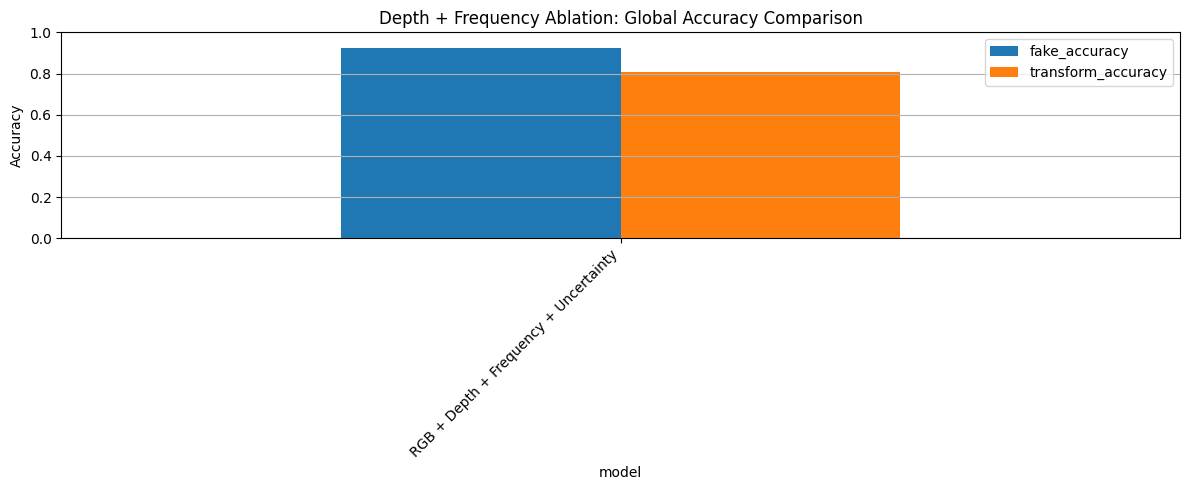

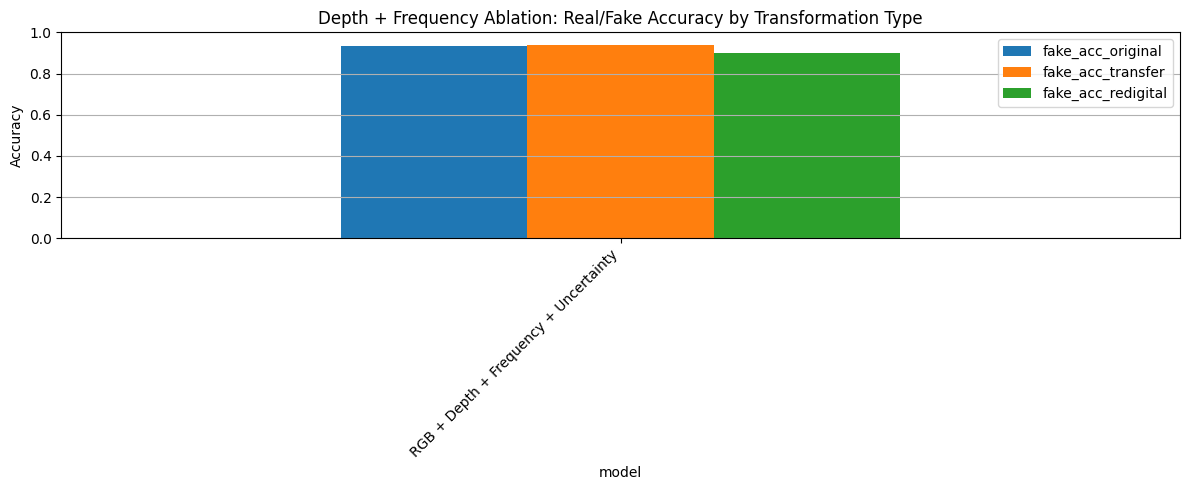

In [50]:
depth_frequency_results = {
    "RGB + Depth + Frequency + Uncertainty": "results/depth_frequency_uncertainty/metrics.json",
    "RGB + Depth + Frequency Gated + Uncertainty": "results/depth_frequency_gated_uncertainty/metrics.json",
}

depth_frequency_comparison_df = build_comparison_df(depth_frequency_results)

depth_frequency_comparison_df

plot_global_accuracy(
    depth_frequency_comparison_df,
    "Depth + Frequency Ablation: Global Accuracy Comparison"
)


plot_fake_accuracy_by_transformation(
    depth_frequency_comparison_df,
    "Depth + Frequency Ablation: Real/Fake Accuracy by Transformation Type"
)

##ViT

#tabelle in caso

In [ ]:
ABLATION_OUTPUT_DIR = Path("results/ablation_study")
ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

depth_comparison_df.to_csv(
    ABLATION_OUTPUT_DIR / "depth_vs_depth_edge_comparison.csv",
    index=False,
)

depth_frequency_comparison_df.to_csv(
    ABLATION_OUTPUT_DIR / "depth_frequency_simple_vs_gated_comparison.csv",
    index=False,
)

print("Saved ablation tables in:", ABLATION_OUTPUT_DIR)